# 🔬 RUN_RESISTENCES: Análisis de Runs de Resistencias de Precisión

**Notebook para analizar runs de calibración electrónica con resistencias de precisión.**

Estos runs usan resistencias PDHD-HP en lugar de sensores RTD y se realizan en aire (no en LN2).

## 📋 Cómo usar

1. **Celda 1**: Setup de paths
2. **Celda 2**: Cargar LogFile
3. **Celda 3**: **MODIFICAR AQUÍ** - Ajusta filtros y selecciona archivo
4. **Celda 4**: **CONFIGURAR AQUÍ** - Tiempos y visualización de sensores
5. **Celdas 5-8**: Ejecutar análisis

## 🎯 Parámetros (Celda 3)

- `CALIBSET_PATTERN = 'RESIST_SET'` → Filtra por CalibSetNumber
- `EXCLUDE_PATTERNS = ['_pre']` → Excluye pre-calibraciones
- `filename = "..."` → Archivo a analizar

## ⏱️ Parámetros de Tiempo (Celda 4)

- `tmin = None, tmax = None` → **Últimos 20 minutos del run** (automático)
- `tmin = 20, tmax = 40` → Minutos 20 a 40 desde el inicio
- `tmin = 0, tmax = None` → Desde el inicio hasta el final
- `tmin = 5, tmax = 25` → Minutos 5 a 25 desde el inicio

**Nota**: Para resistencias, se recomienda usar los últimos 20 minutos (tmin=None, tmax=None)

## 📊 Parámetros de Visualización (Celda 4)

- `show_references = True` → Muestra **14 canales** (12 corona + 2 referencias)
- `show_references = False` → Muestra **12 canales** (solo corona, sin referencias)

**Útil para**: Ver claramente solo los 12 sensores de la corona que miden temperaturas similares, sin los 2 canales de referencia.

## 📌 Diferencias vs RUN_BUENO-STS

- **Medio**: Air (no LN2)
- **Sensores**: IDs alfanuméricos (PDHD-HP-1, PDHD-HP-2, etc.)
- **Carpeta datos**: `data/temperature_files/resistences/`
- **CalibSetNumber**: `RESIST_SET0`, `RESIST_SET1`, etc.
- **Tiempos configurables**: Ajusta tmin/tmax según necesidades
- **Visualización flexible**: Activa/desactiva canales de referencia

In [1]:
# Add repo root to sys.path so the package can be imported in-kernel without reinstalling
import sys
from pathlib import Path
repo_root = (Path('../..').resolve())  # notebook is RTD_Calibration_VGP/notebooks -> go up 2 levels
sys.path.insert(0, str(repo_root))
print('Inserted repo root into sys.path:', repo_root)

# Now you can import modules from the package via the package namespace

Inserted repo root into sys.path: /Users/vicky/Desktop/rtd-calibration-ana


In [2]:
# Import local modules via package namespace
from RTD_Calibration_VGP.src.logfile import Logfile
from RTD_Calibration_VGP.src.runSTS import Run  # ← Usamos runSTS.py (funciona para resistencias también)
import pandas as pd

# Read the logfile using repo_root from previous cell
logfile_path = (repo_root / 'RTD_Calibration_VGP' / 'data' / 'LogFile.csv').resolve()
if not logfile_path.exists():
    print(f'Warning: logfile not found at {logfile_path}')
    logfile_df = pd.DataFrame()
else:
    logfiles = Logfile(filepath=str(logfile_path))
    logfile_df = logfiles.log_file
    print("✅ Logfile loaded")
    print(f"   Total rows: {len(logfile_df)}")

CSV file loaded successfully from '/Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/data/LogFile.csv'.
✅ Logfile loaded
   Total rows: 816


In [ ]:
# ═══════════════════════════════════════════════════════════════
# 🎛️  CONFIGURACIÓN - MODIFICAR AQUÍ
# ═══════════════════════════════════════════════════════════════

CALIBSET_PATTERN = 'RESIST_SET'     # Filtra por CalibSetNumber (resistencias)
EXCLUDE_PATTERNS = ['_pre']         # Excluye pre-calibraciones
LIQUID_MEDIA = 'Air'                # Medio: Air (no LN2)

# ═══════════════════════════════════════════════════════════════
# 🔍 FILTRADO AUTOMÁTICO
# ═══════════════════════════════════════════════════════════════

print(f"\n📊 Aplicando filtros...\n")
filtered_df = logfile_df.copy()

# Filtro 1: CalibSetNumber contiene 'RESIST_SET'
if CALIBSET_PATTERN:
    filtered_df = filtered_df[filtered_df['CalibSetNumber'].astype(str).str.contains(CALIBSET_PATTERN, case=False, na=False)]
    print(f"🔍 Filtro 1: CalibSetNumber contiene '{CALIBSET_PATTERN}' → {len(filtered_df)} archivos")

# Filtro 2: Liquid Media = Air
if LIQUID_MEDIA:
    before = len(filtered_df)
    filtered_df = filtered_df[filtered_df['Liquid Media'].astype(str).str.contains(LIQUID_MEDIA, case=False, na=False)]
    print(f"🔍 Filtro 2: Liquid Media = '{LIQUID_MEDIA}' → {len(filtered_df)} archivos")

# Filtro 3: Excluir patrones
for exclude in EXCLUDE_PATTERNS:
    before = len(filtered_df)
    filtered_df = filtered_df[~filtered_df['Filename'].str.contains(exclude, case=False, na=False)]
    excluded = before - len(filtered_df)
    if excluded > 0:
        print(f"🚫 Filtro 3: Excluidos {excluded} archivos con '{exclude}' → {len(filtered_df)} archivos")

print(f"\n📋 Total archivos disponibles: {len(filtered_df)}\n")

if len(filtered_df) > 0:
    print(f"📌 Archivos disponibles (resistencias):\n")
    for idx, row in filtered_df.iterrows():
        print(f"   • {row['Filename']}")
        print(f"     Set: {row['CalibSetNumber']} | Selection: {row['Selection']} | Date: {row['Date']}\n")
else:
    print(f"❌ ERROR: No se encontraron archivos de resistencias")

# ═══════════════════════════════════════════════════════════════
# 📝 SELECCIONAR ARCHIVO ESPECÍFICO
# ═══════════════════════════════════════════════════════════════

# Nombre del archivo a procesar (MODIFICAR para elegir otro)
filename = "20251104_air_STSr10_STSr9_PDHD-HP-25-PDHD-HP-36_4"

if filename not in filtered_df['Filename'].values:
    print(f"\n⚠️  WARNING: '{filename}' NO encontrado")
    if len(filtered_df) > 0:
        filename = filtered_df['Filename'].iloc[0]
        print(f"   → Usando primer archivo: {filename}")
    else:
        raise ValueError("No hay archivos disponibles")
else:
    file_info = filtered_df[filtered_df['Filename'] == filename].iloc[0]
    print(f"\n✅ Archivo seleccionado: {filename}")
    print(f"   CalibSetNumber: {file_info['CalibSetNumber']}")
    print(f"   Selection: {file_info['Selection']}")
    print(f"   Date: {file_info['Date']}")
    print(f"   Liquid Media: {file_info['Liquid Media']}")


📊 Aplicando filtros...

🔍 Filtro 1: CalibSetNumber contiene 'RESIST_SET' → 8 archivos
🔍 Filtro 2: Liquid Media = 'Air' → 8 archivos
🚫 Filtro 3: Excluidos 1 archivos con '_pre' → 7 archivos

📋 Total archivos disponibles: 7

📌 Archivos disponibles (resistencias):

   • 20251023_air_STSr10_STSr9_PDHD-HP-13-PDHD-HP-24_1
     Set: RESIST_SET1 | Selection: nan | Date: 23/10/25

   • 20251023_air_STSr10_STSr9_PDHD-HP-13-PDHD-HP-24_2
     Set: RESIST_SET1 | Selection: nan | Date: 23/10/25

   • 20251023_air_STSr10_STSr9_PDHD-HP-13-PDHD-HP-24_3
     Set: RESIST_SET1 | Selection: nan | Date: 23/10/25

   • 20251023_air_STSr10_STSr9_PDHD-HP-13-PDHD-HP-24_4
     Set: RESIST_SET1 | Selection: nan | Date: 23/10/25

   • 20251103_air_STSr10_STSr9_PDHD-HP-25-PDHD-HP-36_1
     Set: RESIST_SET2 | Selection: nan | Date: 03/11/25

   • 20251103_air_STSr10_STSr9_PDHD-HP-25-PDHD-HP-36_2
     Set: RESIST_SET2 | Selection: nan | Date: 03/11/25

   • 20251104_air_STSr10_STSr9_PDHD-HP-25-PDHD-HP-36_3
     Set:

In [4]:
# ═══════════════════════════════════════════════════════════════
# ⏱️  CONFIGURACIÓN DE TIEMPOS - MODIFICAR AQUÍ
# ═══════════════════════════════════════════════════════════════

# Opciones para tmin y tmax (tiempos en minutos desde el inicio del run):
# 1. None, None → Últimos 20 minutos del run (automático)
# 2. 20, 40 → Minutos 20 a 40 desde el inicio
# 3. 0, None → Desde el inicio hasta el final

tmin = None  # None = últimos 20 minutos
tmax = None  # None = hasta el final del run

# ═══════════════════════════════════════════════════════════════
# 📊 CONFIGURACIÓN DE SENSORES EN PLOTS - MODIFICAR AQUÍ
# ═══════════════════════════════════════════════════════════════

# show_references: Controla si se muestran los canales 13 y 14 (referencias)
# - True  → Muestra los 14 canales completos (corona + 2 referencias)
# - False → Muestra solo los 12 primeros canales (corona, sin referencias)

show_references = False  # True = 14 canales | False = 12 canales (solo corona)

# ═══════════════════════════════════════════════════════════════

# Create Run instance
print(f"\n🔄 Cargando run: {filename}...\n")

if tmin is None and tmax is None:
    print("⏱️  Modo automático: Últimos 20 minutos del run")
else:
    print(f"⏱️  Intervalo configurado: {tmin if tmin is not None else 'inicio'} - {tmax if tmax is not None else 'final'} minutos")

if show_references:
    print("📊 Modo de visualización: 14 canales (corona + referencias)")
else:
    print("📊 Modo de visualización: 12 canales (solo corona, sin referencias)")

run = Run(filename=filename, logfile=logfile_df, tmin=tmin, tmax=tmax, show_references=show_references)

print("\n✅ Temperature data loaded:")
print(f"   Rows: {len(run.temperature_data)}")
print(f"   Columns: {list(run.temperature_data.columns)}")
print("\n📊 Primeras filas:")
print(run.temperature_data.head())

print("\n📌 Sensor mapping (IDs de resistencias):")
for channel, sensor_id in run.sensor_mapping.items():
    print(f"   {channel}: {sensor_id}")


🔄 Cargando run: 20251104_air_STSr10_STSr9_PDHD-HP-25-PDHD-HP-36_3...

⏱️  Modo automático: Últimos 20 minutos del run
📊 Modo de visualización: 12 canales (solo corona, sin referencias)
Archivo de temperatura encontrado: /Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/data/temperature_files/Resistences/RESIST_SET2/20251104_air_STSr10_STSr9_PDHD-HP-25-PDHD-HP-36_3.txt
Valores NaN (contador): 0
Empty DataFrame
Columns: [datetime, channel, value]
Index: []
Archivo de temperatura procesado correctamente: /Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/data/temperature_files/Resistences/RESIST_SET2/20251104_air_STSr10_STSr9_PDHD-HP-25-PDHD-HP-36_3.txt
No se detectaron canales defectuosos.
Valores de sensores extraídos (antes de filtrado y conversión): ['PDHD-HP-25' 'PDHD-HP-26' 'PDHD-HP-27' 'PDHD-HP-28' 'PDHD-HP-29'
 'PDHD-HP-30' 'PDHD-HP-31' 'PDHD-HP-32' 'PDHD-HP-33' 'PDHD-HP-34'
 'PDHD-HP-35' 'PDHD-HP-36' '1010' '1009']
IDs de sensores después de la conversión: [


🔄 Generando plots...



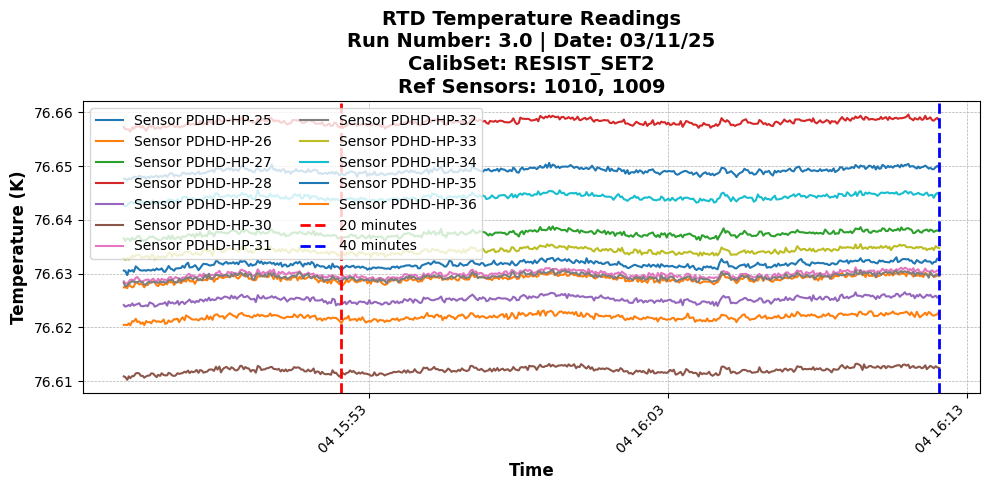

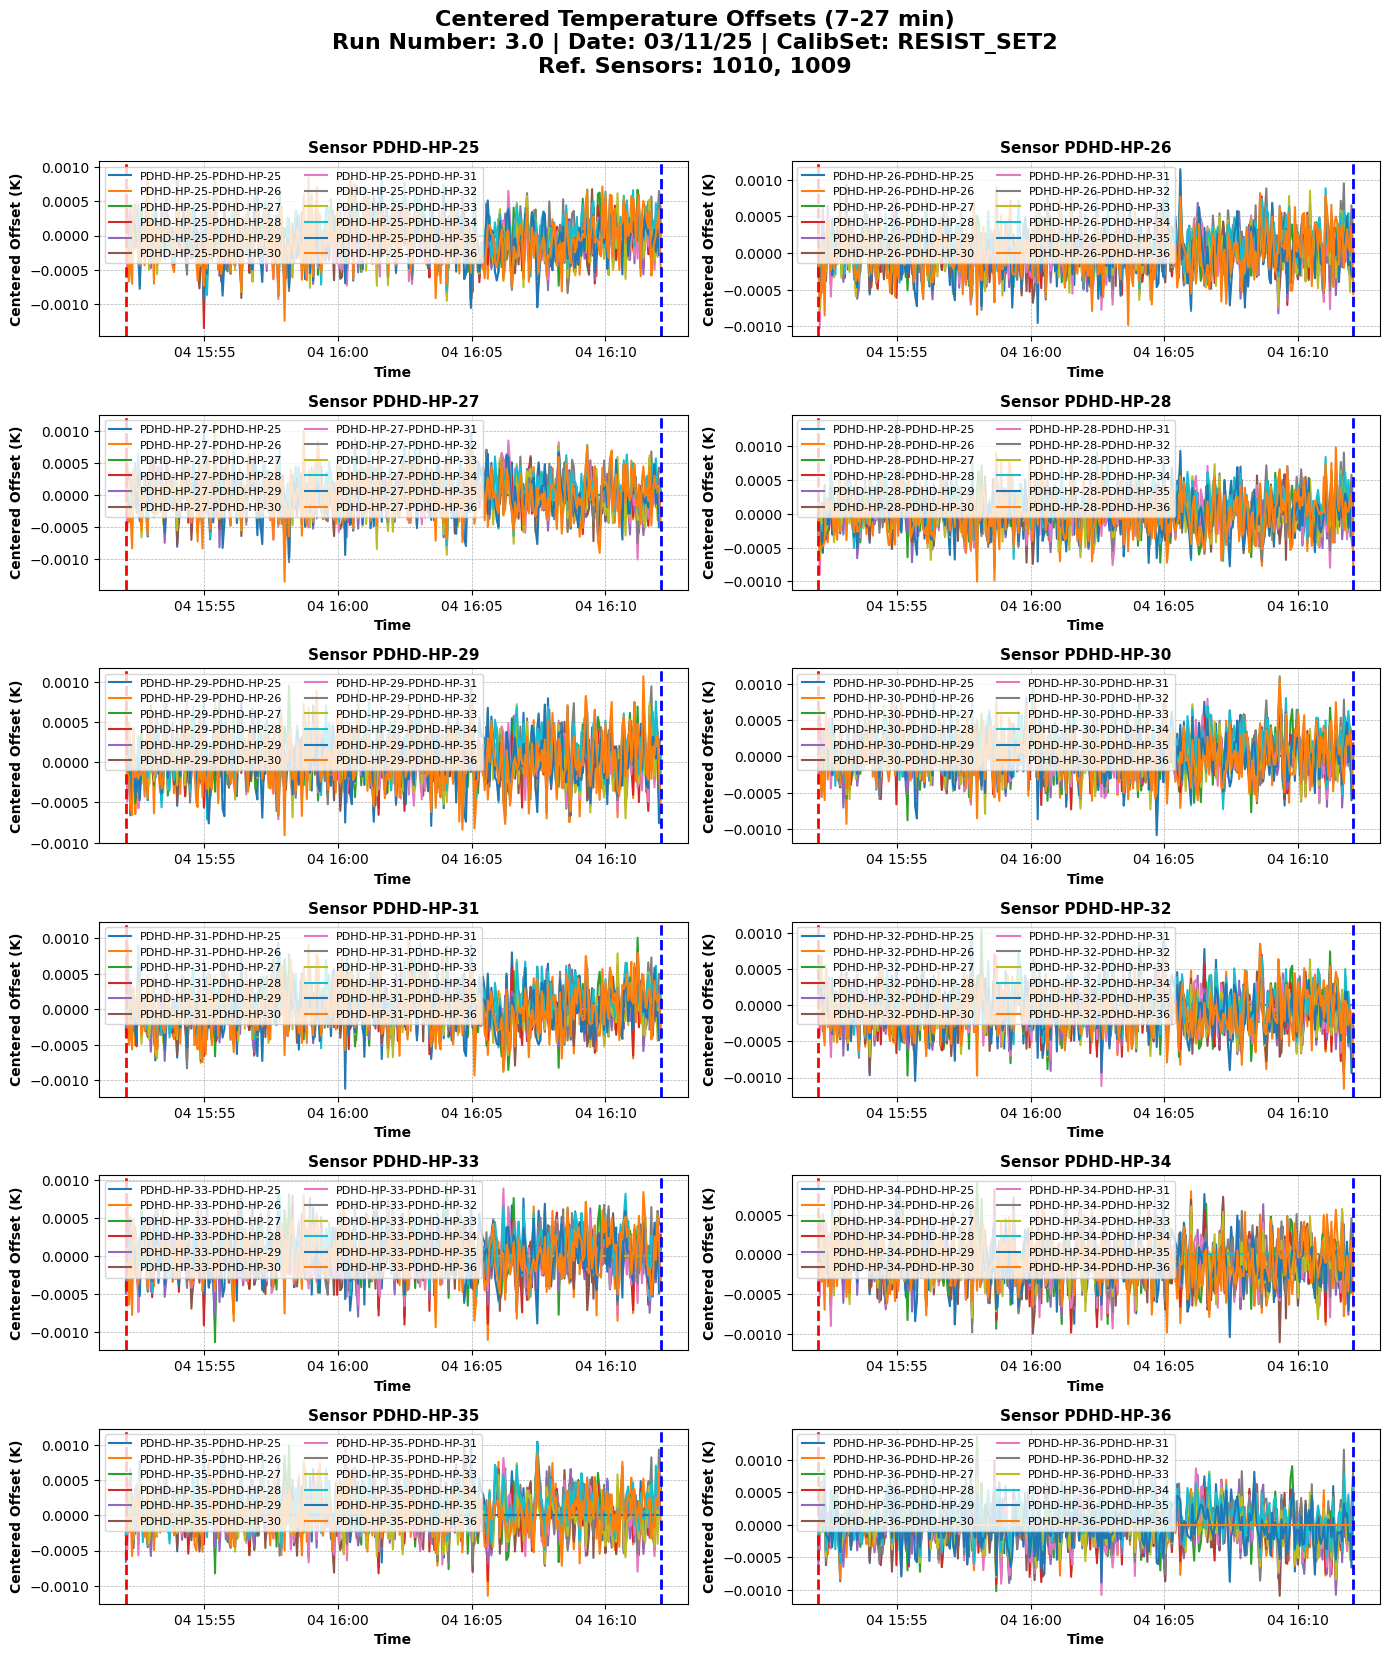

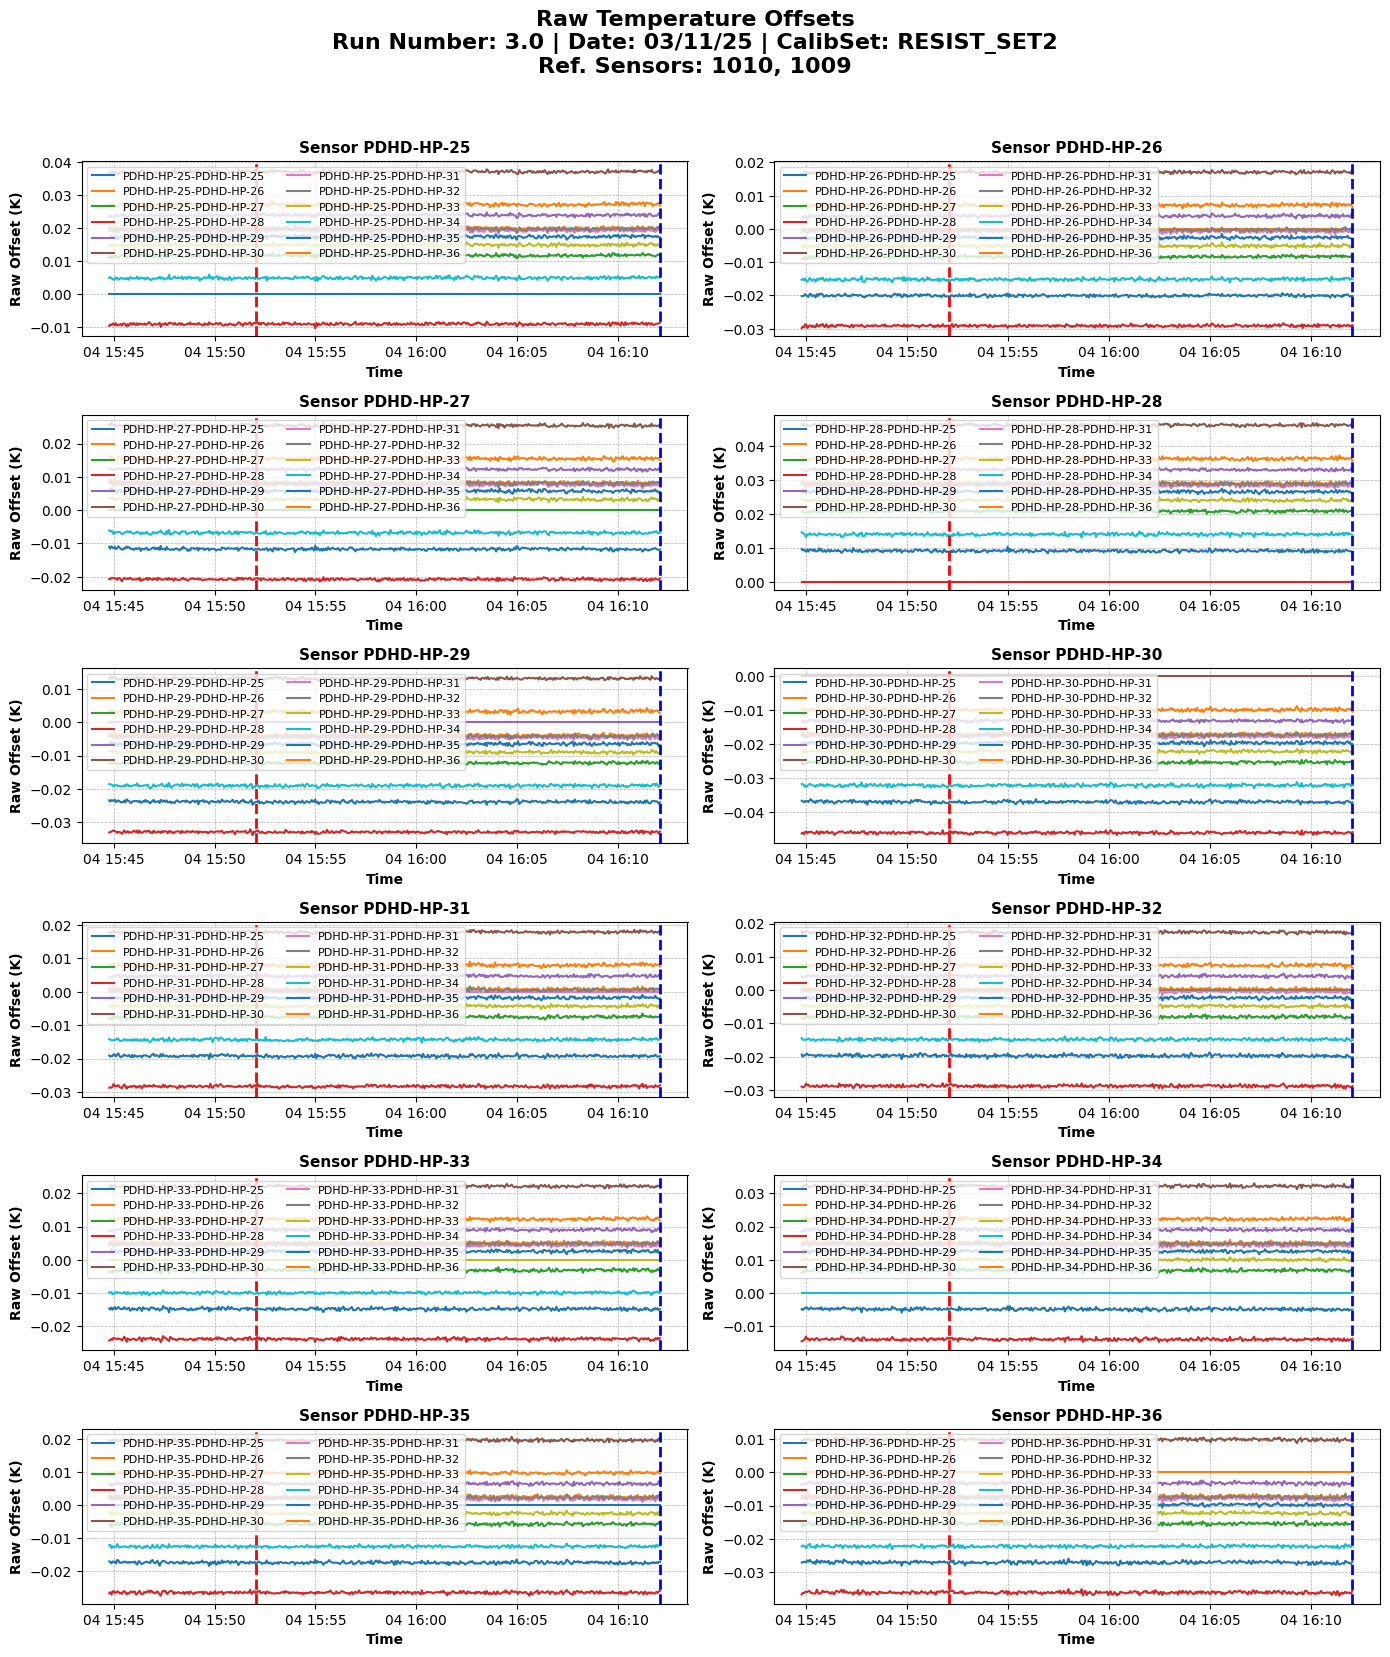

Plots saved in ./Plots/Resistences/

✅ Plots saved in: ./Plots/Resistences/


In [5]:
output_dir = "./Plots/Resistences/"

print(f"\n🔄 Generando plots...\n")
run.save_control_plots(output_dir=output_dir)

print(f"\n✅ Plots saved in: {output_dir}")

In [6]:
print("\n🔄 Calculando offsets...\n")

offsets_df = run.offsets()
print("📊 Matriz de Offsets:")
print(offsets_df)

errors_df = run.stat_err_offsets()
print("\n📊 Errores RMS:")
print(errors_df)


🔄 Calculando offsets...

Offsets medios calculados exitosamente para ventana 20-40 min.
📊 Matriz de Offsets:
            PDHD-HP-25  PDHD-HP-26  PDHD-HP-27  PDHD-HP-28  PDHD-HP-29  \
PDHD-HP-25    0.000000    0.020001    0.011706   -0.009079    0.023918   
PDHD-HP-26   -0.020001    0.000000   -0.008295   -0.029080    0.003917   
PDHD-HP-27   -0.011706    0.008295    0.000000   -0.020785    0.012212   
PDHD-HP-28    0.009079    0.029080    0.020785    0.000000    0.032997   
PDHD-HP-29   -0.023918   -0.003917   -0.012212   -0.032997    0.000000   
PDHD-HP-30   -0.037091   -0.017090   -0.025385   -0.046170   -0.013172   
PDHD-HP-31   -0.019243    0.000758   -0.007537   -0.028322    0.004676   
PDHD-HP-32   -0.019733    0.000268   -0.008027   -0.028812    0.004186   
PDHD-HP-33   -0.014913    0.005088   -0.003207   -0.023992    0.009005   
PDHD-HP-34   -0.004906    0.015096    0.006801   -0.013984    0.019013   
PDHD-HP-35   -0.017432    0.002569   -0.005726   -0.026511    0.006487   
PD


🔄 Generando plot RMS vs tiempo...

Gráfico guardado en: ./Plots/Resistences/20251104_air_STSr10_STSr9_PDHD-HP-25-PDHD-HP-36_3_rms_vs_time.png


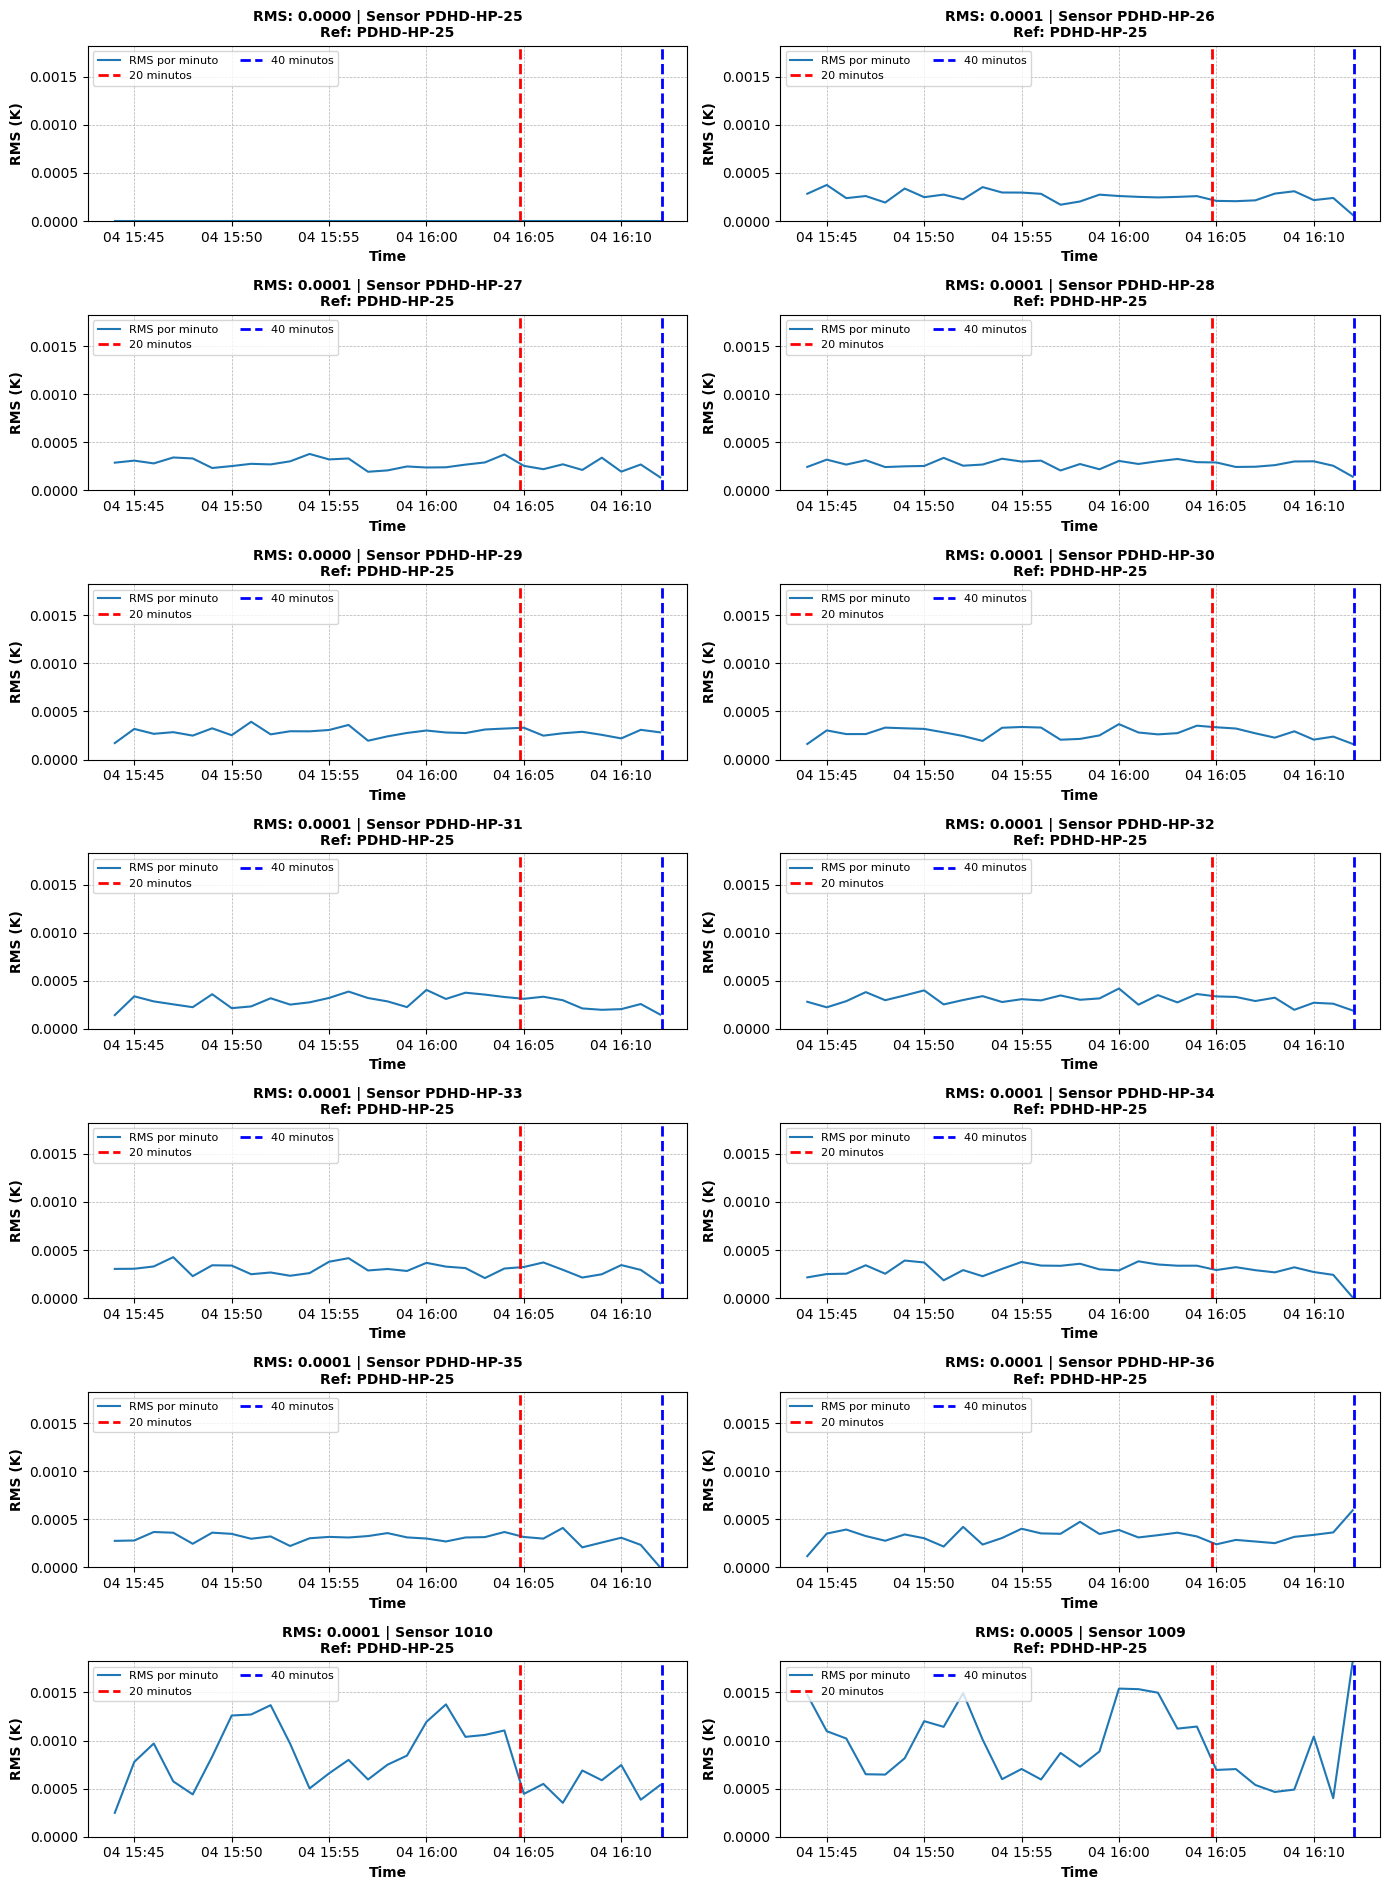


✅ Plot RMS guardado


In [7]:
print("\n🔄 Generando plot RMS vs tiempo...\n")
run.plot_rms_vs_time(output_dir=output_dir)
print("\n✅ Plot RMS guardado")

In [8]:
# Celda para exploración adicional

# Ver info del run:
# print(f"CalibSetNumber: {run.run_info['CalibSetNumber']}")
# print(f"Date: {run.run_info['Date']}")
# print(f"Sensor mapping: {run.sensor_mapping}")

# Ver todos los archivos disponibles:
# for fname in filtered_df['Filename']:
#     print(f"  • {fname}")

# Exportar offsets a CSV:
# offsets_df.to_csv(f"./outputs/{filename}_offsets.csv")
# errors_df.to_csv(f"./outputs/{filename}_errors.csv")